# Seasonal Forecast Analysis - Aug 2026

### Emily Zuetell
### August 7, 2026

# Initialization

In [29]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [3]:
adj = xr.open_zarr('/home/emily_zuetell/projects/poreallas/data/m1_forecast_adj.zarr')

In [13]:
old = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/forecast_adj.zarr").compute()

In [17]:
import seaborn as sns

Text(0.5, 0, 'Adj_Forecast [K]')

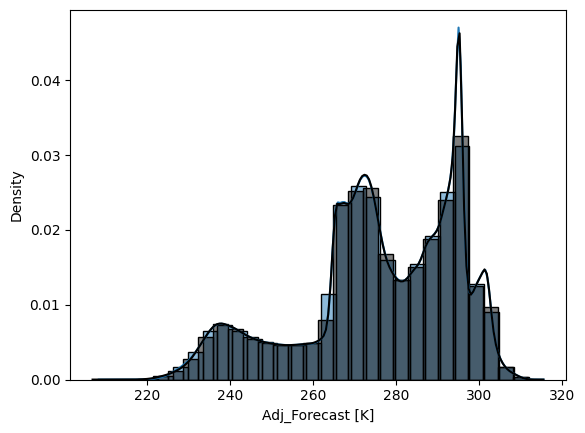

In [19]:
fig, ax = plt.subplots()
old_qdm = old['tas'].sortby("time").sel(time = slice("2027-01-01", "2027-01-31"))
old_qdm = old_qdm.where(old_qdm<1000, drop = True)
new_qdm = adj['tas']

sns.histplot(old_qdm.values.flatten(), kde=True, bins=30, ax = ax, stat = 'density')
sns.histplot(new_qdm.values.flatten(), kde=True, bins=30, ax = ax, stat = 'density', color = 'k')
ax.set_xlabel('Adj_Forecast [K]')

In [24]:
mmt = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/2608_beta_qdm.zarr")

In [36]:
_polygons_mmt = analysis_utils.xarray_to_gpd(mmt['mmt'].sel(age_cohort = 'age65plus'), _polygons)

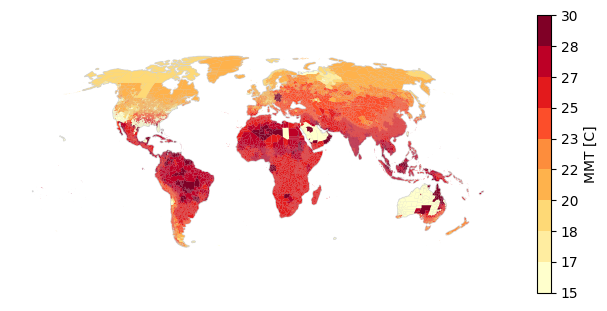

In [47]:
ax = analysis_utils.plot_single(
    _polygons_mmt,
    col='mmt',
    cm = 'YlOrRd',
    vmin = 15, vmax = 30, n_colors = 9,
    sup_title=f"",
    cbar_label= "MMT [C]",
)
fig = ax.figure
fig.savefig("2608_mmt.png", dpi = 600, bbox_inches="tight")

# Load Data

In [25]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]

In [30]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(SOCIOECONOMICS_URI)
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

# Compute Impact

In [ ]:
#Compute the Mortality Impact relative to a Baseline Period for the Projected Effects
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = True)

##For a single age-cohort, use:
#impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = False, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = False, cohort = 'age65plus')

In [ ]:
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = 'number'), _polygons)

In [ ]:
# Plot Impact on a Monthly Basis
fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col='age_weighted_impact',
    cm = 'bwr',
    sup_title=f"",
    cbar_label= impact.units,
)

In [ ]:
# Plot 6-month Cumulative Impact
fig = analysis_utils.plot_aggregate(
    _polygons_impact,
    col='age_weighted_impact',
    agg = 'sum',
    cm = 'bwr',
    sup_title=f"",
    cbar_label= impact.units,
)

In [ ]:
#Ex: Plot 6-month SD
fig = analysis_utils.plot_aggregate(
    _polygons_impact,
    col='age_weighted_impact',
    agg = 'std',
    cm = 'YlOrRd',
    sup_title=f"",
    cbar_label= impact.units,
)

# Climate Data

## Raw Forecast

In [ ]:
forecast = xr.open_zarr(TAS_FORECAST_URI)
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast.mean(dim = 'number'), savefile = None)

In [ ]:
_polygons_forecast = analysis_utils.xarray_to_gpd(forecast_ir['tas'], _polygons)

In [ ]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast,
    col='tas',
    vmin = 273.15,
    vmax = 303,
    cm = 'Reds',
    sup_title=f"",
    cbar_label= 'TAS [K]',
)

## Forecast Anomaly

In [ ]:
#Raw Forecast/Hindcast
s51 = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/parsed/08_forecast_parsed.zarr")
forecast_raw = s51.sel(time=slice('2026-08-01', '2027-01-31')).groupby("time.month").mean()
hindcast_raw = s51.sel(time=slice('1993-08-01', '2016-01-31')).groupby("time.month").mean().sel(month = [1, 8, 9, 10, 11, 12])

In [ ]:
#Compute monthly average anomaly
anomaly = forecast_raw['tas']-hindcast_raw['tas']
anomaly.name = "forecast_anomaly"

## Gridded to Impact Region
anomaly_ir = isku_utils.grid_to_ir(anomaly.mean(dim = 'number'), savefile = None)
_polygons_anomaly = analysis_utils.xarray_to_gpd(anomaly_ir, _polygons)

In [ ]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly,
    col='value',
    cm = 'bwr',
    vmin = -3, vmax = 3,
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
)

fig.savefig("2608_monthly_anomaly.png", dpi = 600, bbox_inches="tight")

In [ ]:
#6 month average anomaly
fig = analysis_utils.plot_aggregate(
    _polygons_anomaly,
    col='value',
    agg = 'mean',
    cm = 'bwr',
    vmin = -3.5, vmax = 3.5, n_colors = 7,
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
)

fig.savefig("2608_cum_anomaly.png", dpi = 600, bbox_inches="tight")

# Build CSV

## Impact Region

In [ ]:
#Load age-weighted data (death rate)
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = True)
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = 'number'), _polygons)
df_ir = _polygons_impact[['region', 'month', 'ISO', 'age_weighted_impact']]

wide = df_ir.pivot(index=['region', 'ISO'], columns='month', values='age_weighted_impact')
wide.columns = [f"month {m}  death rate" for m in wide.columns]
wide['death rate 6mo agg'] = wide.sum(axis=1)
wide.to_csv('2608_rate.csv')
df_rate = wide

In [ ]:
wide

In [ ]:
#Load age-weighted data (death rate)
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = False, age_weight = True)
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = 'number'), _polygons)
df_ir = _polygons_impact[['region', 'month', 'ISO', 'age_weighted_impact']]

wide = df_ir.pivot(index=['region', 'ISO'], columns='month', values='age_weighted_impact')
wide.columns = [f"month {m}  total deaths" for m in wide.columns]
wide['total deaths 6mo agg'] = wide.sum(axis=1)
wide.to_csv('2608_total.csv')
df_total = wide

In [ ]:
df_total.sort_values("total deaths 6mo agg", ascending = True)

## By Country

In [ ]:
def gdp_quartile(da_gdppc):
    # Determine quartiles from IR-level GDP per Capita (gdppc)
    quartile_labels = pd.qcut(da_gdppc.values, q=4, labels=['low', 'mid-low', 'mid-high', 'high'])
    quartile_da =  xr.DataArray(
        quartile_labels.astype(str),
        dims=da_gdppc.dims,
        coords=da_gdppc.coords,
        name='gdp_quartile'
    )
    return xr.Dataset({'gdppc': da_gdppc, 'gdp_quartile': quartile_da}) 

#Load age-weighted data (total deaths)
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = False, age_weight = True)
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = 'number').sum(dim = 'month'), _polygons)
# Population-weighted total deaths
df_country = _polygons_impact[['age_weighted_impact', 'ISO']].groupby('ISO').sum()

#Load data for all age cohorts
for cohort in ['age0to4', 'age5to64', 'age65plus']:
    impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = False, age_weight = False, cohort = cohort)
    _polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = 'number').sum(dim = 'month'), _polygons)
        
    col_i = f'{cohort}_impact'
    df_country[col_i] = _polygons_impact[[col_i, 'ISO']].groupby('ISO').sum()

#World Bank Income Rankings
#income_class = pd.read_csv(os.path.join(DATA_DIR, "income_class_2025.csv")) 
#out_df = df_country.merge(income_class, how = 'left', left_on = 'ISO', right_on = 'Code')

#Pop-weighted GDP by Country
socioeconomics = socioeconomics.load()
gdp_quartile_df = gdp_quartile(
    socioeconomics.groupby('iso3').map(lambda ds: ds['gdppc'].weighted(ds['pop']).mean())
).to_dataframe()

pop_df = socioeconomics[['iso3', 'pop', 'pop0to4', 'pop5to64', 'pop65plus']].groupby('iso3').sum()

out_df = df_country.reset_index().merge(gdp_quartile_df.reset_index(), how = 'left', left_on = 'ISO', right_on = 'iso3')
out_df = out_df.merge(pop_df.to_dataframe().reset_index(), how = 'left', left_on = 'ISO', right_on = 'iso3')

#Compute Mortality Rates from Total Mortality 
out_df["age_weighted_impact_rate"] = out_df['age_weighted_impact']*100000/out_df['pop']
for cohort in ['age0to4', 'age5to64', 'age65plus']:
    col_t = f'{cohort}_impact_rate'
    col_i = f'{cohort}_impact'
    _cohortstem = cohort[3:]
    col_p = f"pop{_cohortstem}"
    out_df[col_t] = out_df[col_i]*100000/out_df[col_p]

out_df = out_df[["ISO", "gdppc", "gdp_quartile",
                 "age_weighted_impact", "age_weighted_impact_rate", "pop",
                 "age0to4_impact", "age0to4_impact_rate", "pop0to4",
                 "age5to64_impact", "age5to64_impact_rate", "pop5to64",
                 "age65plus_impact", "age65plus_impact_rate", "pop65plus",
                 ]]
out_df.to_csv("2608_impact_country_gdppc.csv", index = False)

In [ ]:
out_df.sort_values("age_weighted_impact_rate", ascending = False)

# Response Function Plot

In [ ]:
### TEST DATA ###
# IR Climate Data
forecast_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_forecast_GMFD_tas.zarr"))-273.15
reanalysis_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_reanalysis_GMFD_tas.zarr"))-273.15

#Intermediate Betas/MMT from Project.Py
betas_mmt = xr.open_zarr(os.path.join(DATA_DIR, "beta_mmt_GMFD.zarr"))

In [ ]:
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import cartopy.crs as ccrs
from scipy.interpolate import interp1d
from shapely import box

import diagnostic_utils
importlib.reload(diagnostic_utils)

### Analysis Options ###
rate = True # Mortality Rate vs Total Deaths
hotonly = False # Hot-Only Deaths
age_weight = False #Proportional Age-weighting vs single age group
density_hist = False #Controls daily data histograms (not computation normalization)

### Region Selection ###
region_filters = [
    "PAK.2.5.27",
    "IND.16.203.735",
    "BRA.7.804.1862",
    "IND.29.439.1743",
    "CHN.11.109.767",  # set to None for global
    "COD.3.15.51",
    "THA.76.909.5787",
    "HRV.R4acd3465906d6fba",
    "EGY.8",
    "BRA.9.R7ae8d9b7a4e0454f",
    "ZMB.9.67",
    "USA.14.608",
]

region_filter = "EGY.8"

# Compute Impact
projected = effect
regional_sum = analysis_utils.compute_impact(projected, socioeconomics, baseline_period= baseline_period, hotonly = hotonly, rate = rate, age_weight = age_weight)

#Get Months
months = regional_sum.month.values

### Load Climate Data ###
#Select representative ensemble member
forecast_slice = forecast_gmfd['tas'].sel(number = 1)
forecast_local = forecast_slice.sel(region = region_filter)

#Select representative year
reanalysis_slice = reanalysis_gmfd['tas'].sel(time=slice('2000-01-01', '2000-12-31'))
month_mask = reanalysis_slice.month.isin(months).compute()
reanalysis_slice = reanalysis_slice.where(month_mask, drop=True)
reanalysis_local = reanalysis_slice.sel(region = region_filter)

combined = np.concat([forecast_local.values.flatten(), reanalysis_local.values.flatten()])
xmin, xmax = np.percentile(combined, [1, 100])

# Compute Cumulative Effect
cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(forecast_slice, reanalysis_slice, region_filter, months, hotonly = hotonly)

In [ ]:
#Histogram

b_color = "#999999"
f_color = "#ffbb6f"
r_color = "#5e4c5f"

fig, (ax_hist, ax_cdf) = plt.subplots(
    2, 1, sharex=True, figsize=(6, 6),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08}
)


ref_vals = betas_mmt['mmt'].sel(region=region_filter).sel(age_cohort='age65plus')
betas = betas_mmt['beta_hotonly'] if hotonly else betas_mmt['beta']
da_temp_bins = betas.sel(region=region_filter).sel(age_cohort='age65plus')
da_temp_bins['tas_bin'] = da_temp_bins['tas_bin'] 

# Density histograms on hidden twin axis
bins = da_temp_bins.coords['tas_bin']
ax_hist.hist(reanalysis_local.values.flatten(), bins=bins, alpha=0.5, label="ERA5 (2000)", density=density_hist, color=b_color)
ax_hist.hist(forecast_local.values.flatten(), bins=bins, alpha=0.5, label="Forecast", density=density_hist, color=f_color)
ax_hist.axvline(forecast_local.values.flatten().mean(), color=f_color, linewidth=1, linestyle='--')
ax_hist.axvline(reanalysis_local.values.flatten().mean(), color=b_color, linewidth=1, linestyle='--')
ax_hist.set_ylabel("Count [Days]")
ax_hist.set_xlim(xmin, xmax)

# Response curve on the primary (left) axis
ax_hist2 = ax_hist.twinx()
ax_hist2.step(da_temp_bins.coords['tas_bin'], da_temp_bins.values, where='pre', color=r_color, linewidth=2, label="Response curve")
ax_hist2.axvline(ref_vals.values, color=r_color, linewidth=1, label="MMT")
ax_hist2.set_ylabel("Daily Response 65+ \n [deaths/100k]")
ax_hist2.set_ylim(0, 10)
ax_hist2.set_xlim(xmin, xmax)

# Weighted CDFs in their own subplot below
era5_centers, era5_cdf, fc_centers, fc_cdf = cdf_data

ax_cdf.set_ylabel("6-Month Cum.\n [Deaths/100k]")
ax_cdf.set_ylim(0, max_cdf+2)
ax_cdf.set_xlim(xmin, xmax)
ax_cdf.set_xlabel("Tas [C]")
ax_cdf.step(fc_centers, fc_cdf, where='post', color=f_color, label="Forecast CDF")
ax_cdf.step(era5_centers, era5_cdf, where='post', color=b_color, label="ERA5 CDF")

#Legend
handles = (ax_hist.get_legend_handles_labels()[0]
            + ax_hist2.get_legend_handles_labels()[0]
            + ax_cdf.get_legend_handles_labels()[0])
labels = (ax_hist.get_legend_handles_labels()[1]
            + ax_hist2.get_legend_handles_labels()[1]
            + ax_cdf.get_legend_handles_labels()[1])
ax_cdf.legend(handles, labels, fontsize=7, loc='upper center',
                bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)
ax_hist.set_title(f'{region_filter}')
fig.savefig(f'response_diagnostic_{region_filter}_2607.png', dpi=600, bbox_inches="tight")